In [129]:
# Import all necessary libraries for data analysis and machine learning
import numpy as np  # for numerical operations and arrays
import pandas as pd  # for data manipulation and dataframes
import scipy  # for scientific computing
from scipy import stats  # for statistical tests
from scipy.stats import norm, t, binom, poisson, expon, chi2, f  # specific statistical distributions
import matplotlib.pyplot as plt  # for creating plots and visualizations
import seaborn as sns  # for enhanced statistical visualizations
import statsmodels  # for statistical modeling
import statsmodels.api as sm  # for regression models (OLS, Logit, etc.)
from statsmodels import stats as sm_stats  # for statistical tests
from statsmodels.stats import weightstats as sswa  # for weighted statistics
from statsmodels.formula.api import ols  # for ordinary least squares regression with formulas
from statsmodels.stats.multicomp import pairwise_tukeyhsd  # for post-hoc ANOVA tests
from statsmodels.stats import proportion as ssp  # for proportion tests
from statsmodels.stats.proportion import proportions_ztest  # for z-test on proportions
import os  # for file and directory operations
import warnings  # to manage warning messages
warnings.filterwarnings("ignore")  # suppress warning messages for cleaner output
from scipy.stats import chi2_contingency  # for chi-square test of independence
from sklearn.model_selection import train_test_split  # to split data into training and testing sets
from sklearn.linear_model import LinearRegression  # for linear regression modeling

In [130]:
# Change working directory to where our data files are located
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')

In [131]:
# KEY MACHINE LEARNING CONCEPTS:

# Binary logistic regression: used when the outcome has only 2 categories (yes/no, 0/1)
# Nominal logistic regression: used when outcome has 3+ categories with no natural order (e.g., red/blue/green)
# Overfitting: when a model is too complex and memorizes training data instead of learning patterns
# Bias: error from training data; high bias means model is too simple (underfitting)
# Variance: error from test data; high variance means model is too complex (overfitting)



# NAMING CONVENTION: first word = actual correctness, second word = model's prediction

```text
CONFUSION MATRIX TERMS (for classification models):

 True Positive (TP) : model correctly predicted positive class
 True Negative (TN) : model correctly predicted negative class
 False Positive (FP): model incorrectly predicted positive (Type I error)
 False Negative (FN): model incorrectly predicted negative (Type II error)

In [132]:
# Load the education dataset from Excel file into a pandas dataframe
df = pd.read_excel('data/EduData.xlsx')

In [133]:
# Display first 5 rows to see the structure and content of the dataset
df.head()

,TechnicalScore,ExpectedSalary,SocialSkillsScore,Education,JobOffer
0,14.413328,5.411551,62.684845,BTech,0
1,88.897319,6.890750,80.996942,BTech,1
2,93.327958,9.617579,33.757440,BTech,1
3,45.111248,6.030990,47.496977,BTech,0
4,39.435319,9.415410,14.132314,MLExpert,0


In [134]:
# Check all unique values in the Education column to see available categories
np.unique(df['Education'])

array(['BTech', 'MCA', 'MLExpert'], dtype=object)

In [135]:
# Check unique values in JobOffer column (our target variable - what we want to predict)
np.unique(df['JobOffer'])

array([0, 1])

In [136]:
# Count how many times each value appears in JobOffer column to check for class imbalance
df.JobOffer.value_counts()

JobOffer
0    430
1    270
Name: count, dtype: int64

In [137]:
# Convert Education column (categorical) into dummy variables for the model to understand
edu_dummy = pd.get_dummies(df.Education, drop_first=True).astype(int)  # drop_first=True avoids multicollinearity
df = df.drop('Education', axis=1)  # remove original Education column since we created dummies
df = pd.concat([df, edu_dummy], axis=1)  # add dummy columns to the dataframe

# Split data: 80% for training the model, 20% for testing it (random_state=20 for reproducibility)
x_train, x_test, y_train, y_test = train_test_split(
	df.drop('JobOffer', axis=1), df.JobOffer, random_state=20, test_size=0.2
)

# Add intercept/constant term to the training data (required for statsmodels)
x_train = sm.add_constant(x_train, prepend=False)

# Fit logistic regression model (used because JobOffer is binary: 0 or 1)
mod1 = sm.Logit(y_train, x_train).fit()


print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.422088
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               JobOffer   No. Observations:                  560
Model:                          Logit   Df Residuals:                      554
Method:                           MLE   Df Model:                            5
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.3715
Time:                        17:32:58   Log-Likelihood:                -236.37
converged:                       True   LL-Null:                       -376.06
Covariance Type:            nonrobust   LLR p-value:                 2.701e-58
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
TechnicalScore        0.0614      0.005     12.022      0.000       0.051       0.071
Expected

In [138]:
# Logistic Regression Hypothesis Testing (for each predictor):
#
# Null Hypothesis (H₀): The predictor has NO effect on the probability of getting a job offer
#                       (i.e., coefficient β = 0)
# Alternative Hypothesis (H₁): The predictor DOES have an effect on the probability of getting a job offer
#                               (i.e., coefficient β ≠ 0)
#
# Decision Rule: Reject H₀ if p-value < 0.05 (at 5% significance level)
#
# Results interpretation:
#
# 1. TechnicalScore (p = 0.000):
#    - Reject H₀: Technical score SIGNIFICANTLY affects job offer probability
#    - Positive coefficient (0.0976) means higher technical score increases the odds of getting a job offer
#
# 2. ExpectedSalary (p = 0.003):
#    - Reject H₀: Expected salary SIGNIFICANTLY affects job offer probability
#    - Negative coefficient (-0.6319) means higher salary expectations DECREASE the odds of getting a job offer
#
# 3. SocialSkillsScore (p = 0.793):
#    - Fail to reject H₀: Social skills score does NOT significantly affect job offer probability
#    - The effect is not statistically different from zero
#
# 4. MCA (p = 0.354):
#    - Fail to reject H₀: Having an MCA degree does NOT significantly affect job offer probability
#    - The effect is not statistically different from zero
#
# 5. MLExpert (p = 0.019):
#    - Reject H₀: Being an ML expert SIGNIFICANTLY affects job offer probability
#    - Positive coefficient (1.3545) means ML expertise increases the odds of getting a job offer
#
# 6. const/intercept (p = 0.004):
#    - Significant baseline log-odds when all predictors are zero
#
# Summary:
# Significant predictors (p < 0.05): TechnicalScore, ExpectedSalary, MLExpert
# Non-significant predictors (p ≥ 0.05): SocialSkillsScore, MCA
#
# Note: The reference category for Education is the one dropped (alphabetically first after drop_first=True)

In [139]:
# null hypothesis - the predictor has no effect on the probability of getting a job offer

# here getting the job DOES depend on Technical score because the p-value is 0.000 (reject H₀)

# anything with p-value > 0.05 means we fail to reject H₀ (SocialSkillsScore and MCA are not significant)

In [140]:
# UNDERSTANDING PROBABILITY AND ODDS (important for logistic regression):
# p = probability of event occurring (e.g., getting a job offer)
# 1-p = probability of event NOT occurring

# p/(1-p) = odds ratio (how likely the event is to happen vs not happen)# Example: if p=0.75, then odds = 0.75/0.25 = 3 (3 times more likely to happen than not)

In [141]:
# Prepare test data and make predictions
x_test = sm.add_constant(x_test, prepend=False)  # add constant term for intercept

y_pred = mod1.predict(x_test)  # predict probabilities (not 0/1, but values between 0 and 1)# y_pred contains probability of getting a job offer for each person in test set

In [142]:
# View first 2 rows of test data to see the feature values
x_test[:2]  # shows TechnicalScore, ExpectedSalary, SocialSkillsScore, MCA, MLExpert, const

,TechnicalScore,ExpectedSalary,SocialSkillsScore,MCA,MLExpert,const
535,92.472815,8.656248,3.484288,1,0,1.0
281,85.592896,6.674792,2.576760,0,0,1.0


In [143]:
# View model coefficients (weights for each feature)
mod1.params  # shows how much each feature contributes to the prediction

TechnicalScore       0.061359
ExpectedSalary      -0.440405
SocialSkillsScore    0.006884
MCA                 -0.010096
MLExpert             1.307060
const               -1.072969
dtype: float64

In [144]:
# Manually calculate log-odds for first test sample (to understand what model does internally)

# Formula: log-odds = (TechnicalScore × coef) + (ExpectedSalary × coef) + ... + intercept# This gives us the log-odds (not probability yet)
x1 = 92.472815*0.061359 + 8.656248*(-0.440405) + 3.484288*0.006884 + (-0.010096) - 1.072969

In [145]:
# View the log-odds value
x1  # to convert to probability, we use sigmoid function: p = 1/(1 + e^(-x1))

0.8027053937369997

In [146]:
# View predicted probabilities for first 2 test samples

y_pred[:2]  # 0.69 means 69% probability of getting a job offer (first person)# Values range from 0 (no chance) to 1 (certain to get job)

535    0.690550
281    0.778516
dtype: float64

In [147]:
# Convert probabilities to binary predictions (0 or 1) using threshold of 0.5

y_pred_result = (y_pred >= 0.5).astype(int)  # if probability >= 50%, predict 1 (will get job), else 0 (won't get job)# This is the decision rule: we're saying "if there's at least 50% chance, predict they'll get the job"

In [148]:
# View first 5 binary predictions
y_pred_result[:5]  # shows 1 (predicted to get job) or 0 (predicted not to get job)

535    1
281    1
324    0
645    0
10     0
dtype: int64

In [149]:
from sklearn.metrics import confusion_matrix

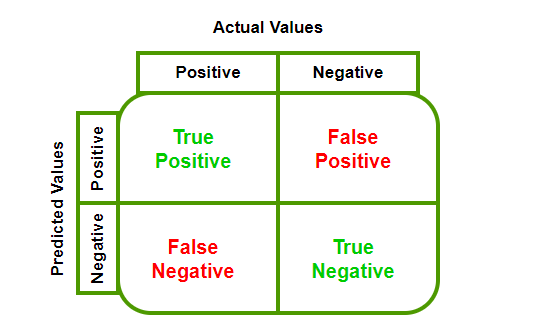

$$
\text{Model Accuracy} = \frac{TP + TN}{TN + FP + FN + TP}
$$

#### precision (1 - positive)
$$\text{precision}_{1} = \frac{TP}{TP + FP}$$

#### Precision (0- negative)
$$\text{precision}_{0} = \frac{TN}{TN + FN}$$

#### Recall / Sensitivity (1- positive)
$$\text{Recall}_{1} = \frac{TP}{TP + FN}$$

#### Recall / Specificity (0 - negative)
$$\text{Recall}_{0} = \frac{TN}{TN + FP}$$

#### false positive rate (FPR)
$$\text{FPR} = \frac{FP}{FP + TN}$$

#### False negative rate (FNR)
$$\text{FNR} = \frac{FN}{FN + TP}$$

#### Accuracy
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

#### F1-Score (Positive Class – 1)
$$\text{F1}_{1} = \frac{2TP}{2TP + FP + FN}$$

#### F1-Score (Negative Class – 0)
$$\text{F1}_{0} = \frac{2TN}{2TN + FP + FN}$$


In [150]:
108/140

0.7714285714285715

In [151]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred_result))

[[72 20]
 [12 36]]


In [152]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_result))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82        92
           1       0.64      0.75      0.69        48

    accuracy                           0.77       140
   macro avg       0.75      0.77      0.76       140
weighted avg       0.78      0.77      0.78       140




#### Harmonic mean of $a$ and $b$ ( **f1-score** ):

$$
H = \frac{2ab}{a + b}
$$

where

a = precision

b = recall

In [153]:
# the coefficients of the continious predictor indicates the change in the logs of odds ratio when the predictor is increased by 1 unit

In [154]:
x_test = sm.add_constant(x_test,prepend=False)
y_pred = mod1.predict(x_test)

In [155]:
x1 = 92.472815*0.061359 + 8.656248*(-0.440405) + 3.484288*0.006884 + (-0.010096) - 1.072969

In [156]:
y_pred_result = (y_pred>=0.5).astype(int)

In [157]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred_result))

[[72 20]
 [12 36]]


In [158]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_result))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82        92
           1       0.64      0.75      0.69        48

    accuracy                           0.77       140
   macro avg       0.75      0.77      0.76       140
weighted avg       0.78      0.77      0.78       140



In [159]:
mydata = pd.DataFrame([[60,5,50,1,0,1],[70,5,50,1,0,1],[80,5,50,1,0,1]], columns = x_train.columns)
mypred = mod1.predict(mydata)

In [160]:
ods_70 = np.log(0.794817/(1-0.794817))
ods_60 = np.log(0.677131/(1-0.677131))
(ods_70 - ods_60)/10

np.float64(0.06135915488852001)

In [161]:
import math
x = math.sqrt(4)

In [162]:
y = np.sqrt(4)

In [163]:
type(x)

float

In [164]:
type(y)

numpy.float64

In [165]:
df = pd.read_excel('data/log_loss.xlsx')

In [166]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Case,ActualResult,PredProb,1-PredProb,PredResult,Error,NaN
4,NaN,NaN,1,1,0.7,0.3,1,-0.356673,NaN


In [168]:
# Generate predictions for training data
y_pred_train = mod1.predict(x_train)

log_loss = 0

for ctr in range(len(y_train)):
    if y_train.iloc[ctr]==1:
        log_loss = log_loss + np.log(y_pred_train.iloc[ctr])
    else:
        log_loss = log_loss + np.log(1-y_pred_train.iloc[ctr])

In [173]:
print(mod1.summary())

                           Logit Regression Results                           
Dep. Variable:               JobOffer   No. Observations:                  560
Model:                          Logit   Df Residuals:                      554
Method:                           MLE   Df Model:                            5
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.3715
Time:                        17:37:46   Log-Likelihood:                -236.37
converged:                       True   LL-Null:                       -376.06
Covariance Type:            nonrobust   LLR p-value:                 2.701e-58
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
TechnicalScore        0.0614      0.005     12.022      0.000       0.051       0.071
ExpectedSalary       -0.4404      0.086     -5.125      0.000      -0.609      -0.272
SocialSkillsScore     0.